# Sorting Arrays

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [4]:
def selection_sort(x):
    for i in range(len(x)):
        swap = i + np.argmin(x[i:])
        (x[i], x[swap]) = (x[swap], x[i])
    return x

In [5]:
x = np.array([2, 1, 4, 3, 5])
selection_sort(x)

array([1, 2, 3, 4, 5])

In [6]:
def bogosort(x):
    while np.any(x[:-1] > x[1:]):
        np.random.shuffle(x)
    return x

In [7]:
x = np.array([2, 1, 4, 3, 5])
bogosort(x)

array([1, 2, 3, 4, 5])

In [20]:
x = np.array([2, 1, 4, 3, 5])
print(np.sort(x))
print(x)

[1 2 3 4 5]
[2 1 4 3 5]


In [22]:
x = np.array([2, 1, 4, 3, 5])
print(x)
x.sort()    # sort array in-place
print(x)

[2 1 4 3 5]
[1 2 3 4 5]


In [25]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)   # returns the indices of the sorted elements
print(i)
print(x[i])

[1 0 3 2 4]
[1 2 3 4 5]


In [27]:
rng = np.random.default_rng(42)
X = rng.integers(0, 10, (4,6))
X

array([[0, 7, 6, 4, 4, 8],
       [0, 6, 2, 0, 5, 9],
       [7, 7, 7, 7, 5, 1],
       [8, 4, 5, 3, 1, 9]])

In [28]:
np.sort(X, axis=0)

array([[0, 4, 2, 0, 1, 1],
       [0, 6, 5, 3, 4, 8],
       [7, 7, 6, 4, 5, 9],
       [8, 7, 7, 7, 5, 9]])

In [29]:
np.sort(X, axis=1)

array([[0, 4, 4, 6, 7, 8],
       [0, 0, 2, 5, 6, 9],
       [1, 5, 7, 7, 7, 7],
       [1, 3, 4, 5, 8, 9]])

In [30]:
x = np.array([7, 2, 3, 1, 6, 5, 4])
np.partition(x, 3)

array([2, 1, 3, 4, 6, 5, 7])

In [31]:
np.partition(X, 2, axis=1)

array([[0, 4, 4, 7, 6, 8],
       [0, 0, 2, 6, 5, 9],
       [1, 5, 7, 7, 7, 7],
       [1, 3, 4, 5, 8, 9]])

## Example: k-Nearest Neighboors

In [36]:
X = rng.random((10, 2))
X

array([[0.32582536, 0.37045971],
       [0.46955581, 0.18947136],
       [0.12992151, 0.47570493],
       [0.22690935, 0.66981399],
       [0.43715192, 0.8326782 ],
       [0.7002651 , 0.31236664],
       [0.8322598 , 0.80476436],
       [0.38747838, 0.2883281 ],
       [0.6824955 , 0.13975248],
       [0.1999082 , 0.00736227]])

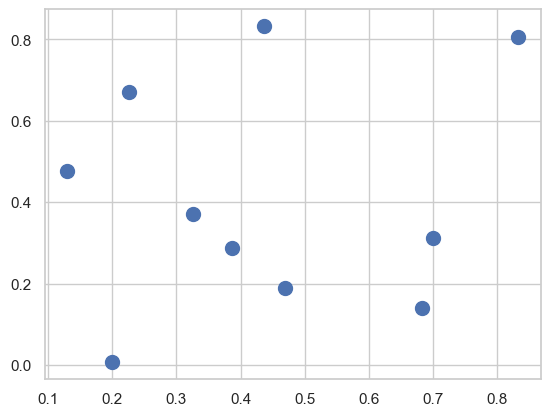

In [43]:
plt.scatter(X[:, 0], X[:, 1], s=100);

In [44]:
# Get distance between each pair of points
dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)

In [48]:
nearest = np.argsort(dist_sq, axis=1)
print(nearest)

[[0 7 2 1 3 5 9 8 4 6]
 [1 7 8 0 5 9 2 3 4 6]
 [2 3 0 7 1 4 9 5 8 6]
 [3 2 4 0 7 1 5 6 9 8]
 [4 3 6 2 0 7 5 1 8 9]
 [5 8 1 7 0 6 4 9 3 2]
 [6 4 5 3 0 7 8 1 2 9]
 [7 0 1 5 2 8 9 3 4 6]
 [8 5 1 7 0 9 2 6 3 4]
 [9 1 7 0 2 8 5 3 4 6]]


In [49]:
K = 2
nearest_partition = np.argpartition(dist_sq, K + 1, axis=1)

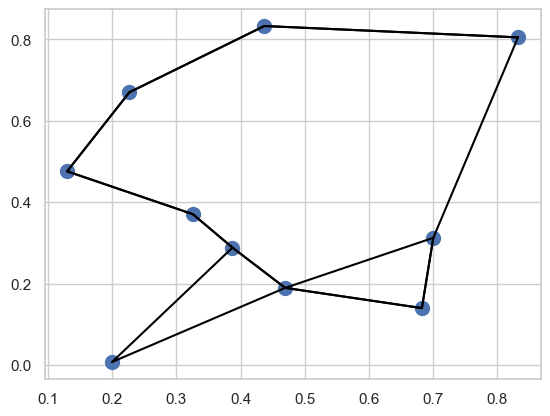

In [53]:
plt.scatter(X[:, 0], X[:, 1], s=100)
K = 2
for i in range(X.shape[0]):
    for j in nearest_partition[i, :K+1]:
        plt.plot(*zip(X[j], X[i]), color='black')